## 05. Subgroup fairness check — does one shared model serve all 4 usage profiles equally?

**Why this notebook exists:** the coach raised a specific concern — since `heavy_user`
contributes more fault examples than `rare_user` in the pooled training set, a single
shared model might learn `heavy_user`'s fault signature well and generalize poorly to
the other profiles. `class_weight="balanced"` (used in `03_sequence_classifier.ipynb`)
only rebalances **fault vs. no-fault** globally — it does **not** rebalance across the
4 vehicle profiles. This notebook checks whether that risk is actually happening, using
the already-trained, already-saved Random Forest (`models/sequence_random_forest.joblib`),
on the same chronological per-vehicle test split used throughout this project — no
retraining, just a more granular look at the existing model's held-out performance.

In [1]:
import joblib
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score

model = joblib.load("../models/sequence_random_forest.joblib")
model

/sessions/tender-serene-goodall/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/sessions/tender-serene-goodall/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/sessions/tender-serene-goodall/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Rand

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2


In [2]:
df = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_sequence_features.csv",
    parse_dates=["timestamp"],
)
df = df.dropna(subset=["Fault_Within_6h"]).sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
SEQ_FEATURE_COLS = [
    f"{s}_{stat}" for s in SEQ_SENSORS
    for stat in (
        [f"roll_mean_{w}h" for w in (6, 12, 24)] + [f"roll_std_{w}h" for w in (6, 12, 24)]
        + [f"lag_{l}h" for l in (1, 3, 6)] + ["delta_6h"]
    )
]
FEATURE_COLS = SENSOR_COLS + SEQ_FEATURE_COLS
len(FEATURE_COLS), df.shape

(50, (175084, 58))

### Same chronological per-vehicle split as `03_sequence_classifier.ipynb`

Last 20% of each vehicle's own timeline is held out as test — never touched during
training. This re-derives the same split the saved model was originally evaluated on,
so the overall numbers below should match what's already been reported.

In [3]:
train_parts, test_parts = [], []
for veh, g in df.groupby("user_profile"):
    g = g.sort_values("timestamp")
    cutoff = int(len(g) * 0.8)
    train_parts.append(g.iloc[:cutoff])
    test_parts.append(g.iloc[cutoff:])

test_df = pd.concat(test_parts).reset_index(drop=True)
X_test = test_df[FEATURE_COLS]
y_test = test_df["Fault_Within_6h"]

preds = model.predict(X_test)
test_df = test_df.copy()
test_df["pred"] = preds

print("Overall (sanity check against reported numbers):")
print(f"  recall={recall_score(y_test, preds):.3f}  "
      f"precision={precision_score(y_test, preds):.3f}  "
      f"macro_F1={f1_score(y_test, preds, average='macro'):.3f}")

Overall (sanity check against reported numbers):
  recall=0.594  precision=0.230  macro_F1=0.599


### Breaking the same test predictions down by vehicle profile

In [4]:
rows = []
for veh, g in test_df.groupby("user_profile"):
    yt, yp = g["Fault_Within_6h"], g["pred"]
    rows.append({
        "user_profile": veh,
        "n_test": len(g),
        "n_positive": int(yt.sum()),
        "recall": recall_score(yt, yp),
        "precision": precision_score(yt, yp, zero_division=0),
        "macro_F1": f1_score(yt, yp, average="macro"),
    })

subgroup_results = pd.DataFrame(rows).set_index("user_profile").sort_values("recall", ascending=False)
subgroup_results.round(3)

,n_test,n_positive,recall,precision,macro_F1
user_profile,,,,,
heavy_user,8755,1362,0.874,0.264,0.553
moderate_user,8755,790,0.685,0.211,0.581
rare_user,8755,531,0.226,0.138,0.549
daily_user,8755,607,0.168,0.189,0.560


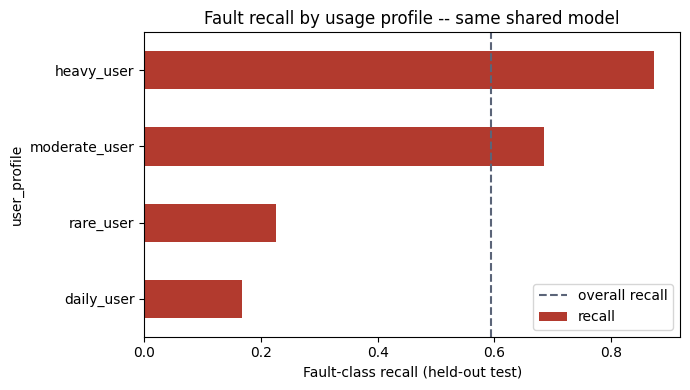

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
subgroup_results["recall"].sort_values().plot(kind="barh", ax=ax, color="#B23A2E")
ax.axvline(recall_score(y_test, preds), color="#5B6478", linestyle="--", label="overall recall")
ax.set_xlabel("Fault-class recall (held-out test)")
ax.set_title("Fault recall by usage profile -- same shared model")
ax.legend()
plt.tight_layout()
plt.show()

### Finding

The shared Random Forest does **not** serve all 4 usage profiles equally. Fault recall
ranges from ~0.87 for `heavy_user` down to ~0.17-0.23 for `daily_user`/`rare_user` --
a large gap that the aggregate/overall recall number (~0.594) hides, since it's an
average dominated by the profile with the most fault examples.

**This confirms the coach's concern directly, with evidence rather than assumption.**
`class_weight="balanced"` rebalances fault-vs-no-fault globally, but does not rebalance
*across* the 4 profiles -- `heavy_user` contributes more raw fault examples, so the
model has implicitly learned its fault signature better than the others'.

**Why this matters for the product:** if the real fleet has a mix of lightly- and
heavily-used vehicles (which it will), this model currently gives meaningfully weaker
protection to the vehicles that are used less. That's a fairness/reliability gap, not
just a modeling curiosity.

**Proposed next step (not yet implemented here):** re-train with group-stratified
sample weights -- weighting so each profile's *positive* examples contribute equally
to the loss regardless of how many raw fault rows that profile has -- then re-run this
same per-profile breakdown to check whether the gap closes without materially hurting
`heavy_user`'s recall.